# Chapter 2a — Ratings and rating transitions

Covers rating-scale construction and Markov transition-matrix analysis
(Roncalli, *Handbook of Sustainable Finance*): how a continuous score gets
turned into discrete rating buckets, and how a rating transition matrix
behaves over time -- stationary distributions, hitting times, generator
matrices, and continuous-time migration probabilities.

The chapter's scoring-methodology material (Gini/KS curves, backtesting,
Shannon-entropy scoring, and the LPI/RLI case studies) is a separate,
mostly-independent topic and lives in
[`02b_scoring_methodology.ipynb`](02b_scoring_methodology.ipynb) instead of
one long notebook.

Uses `quanttoolbox.sustainable_finance.entropy.estimate_markov_generator`
for the generator-repair step; everything else here is `numpy`/`scipy`
(`scipy.linalg` for matrix logarithms, exponentials, and fractional
powers).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import expm, logm, fractional_matrix_power, null_space

from quanttoolbox.sustainable_finance.entropy import estimate_markov_generator

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"
RATINGS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]

## 1. Rating scale construction

Three ways of turning a continuous score into a small number of discrete
rating buckets.

### 1.1 Equal-width buckets on the standard normal

Seven buckets of width 1, centered on
$z_k \in \{-2.5, -1.5, \dots, 3.5\}$; the probability mass of bucket $k$ is
$\Phi(z_k+1) - \Phi(z_k)$.

In [2]:
K = 7
k = np.arange(1, K + 1)
z_k = -2.5 + (k - 1)  # seqa(-2.5, 1, K)
p_k = stats.norm.cdf(z_k + 1) - stats.norm.cdf(z_k)

pd.DataFrame({"k": k, "z_k": z_k, "p_k (%)": (100 * p_k).round(2)})

,k,z_k,p_k (%)
0,1,-2.5,6.06
1,2,-1.5,24.17
2,3,-0.5,38.29
3,4,0.5,24.17
4,5,1.5,6.06
5,6,2.5,0.60
6,7,3.5,0.02


### 1.2 Equal-probability buckets

Boundaries $s_k = \Phi^{-1}(k/K)$ are chosen so
each bucket carries exactly $1/K$ of the probability mass by
construction -- the standard "quantile" rating scale.

In [3]:
s_k = stats.norm.ppf(k / K)
p_k_eq = np.diff(stats.norm.cdf(s_k), prepend=0.0)

pd.DataFrame({"k": k, "s_k": s_k.round(3), "p_k (%)": (100 * p_k_eq).round(2)})

,k,s_k,p_k (%)
0,1,-1.068,14.29
1,2,-0.566,14.29
2,3,-0.180,14.29
3,4,0.180,14.29
4,5,0.566,14.29
5,6,1.068,14.29
6,7,inf,14.29


### 1.3 A beta-distribution-based scale

Instead of slicing a normal distribution, each
bucket's probability is $F_{\text{Beta}(\alpha,\beta)}(k/K) -
F_{\text{Beta}(\alpha,\beta)}((k-1)/K)$ -- varying $(\alpha,\beta)$ changes how
concentrated ratings are around the middle versus the tails.

In [4]:
s1 = np.arange(K) / K
s2 = (np.arange(K) + 1) / K
alpha = np.array([1.0, 2.0, 3.0, 0.25, 2.5, 1.5, 0.75])
beta_ = np.array([1.0, 2.0, 3.0, 0.25, 1.5, 2.5, 1.00])

p_beta = stats.beta.cdf(s2, alpha, beta_) - stats.beta.cdf(s1, alpha, beta_)

pd.DataFrame({
    "alpha": alpha, "beta": beta_, "p_k (%)": (100 * p_beta).round(1),
})

,alpha,beta,p_k (%)
0,1.00,1.00,14.3
1,2.00,2.00,14.3
2,3.00,3.00,22.3
3,0.25,0.25,5.5
4,2.50,1.50,22.3
5,1.50,2.50,6.4
6,0.75,1.00,10.9


## 2. A real-world credit rating transition matrix

A published 7-state one-year rating transition
matrix (rows/columns AAA...CCC), and its 2-year and 5-year equivalents by
matrix power (assuming a time-homogeneous Markov chain).

In [5]:
P_credit = np.array([
    [91.61,  6.70,  1.02,  0.49,  0.18,  0.00,  0.00],
    [ 4.13, 82.41, 12.15,  0.90,  0.31,  0.10,  0.00],
    [ 0.17, 15.54, 72.69, 10.62,  0.80,  0.14,  0.04],
    [ 0.06,  1.30, 19.53, 69.28,  9.30,  0.47,  0.06],
    [ 0.04,  0.19,  1.55, 21.57, 67.55,  8.81,  0.29],
    [ 0.03,  0.05,  0.25,  1.49, 21.82, 73.43,  2.93],
    [ 0.00,  0.04,  0.24,  0.28,  2.47, 16.23, 80.74],
]) / 100

assert np.allclose(P_credit.sum(axis=1), 1.0, atol=1e-6)

P_credit_2y = P_credit @ P_credit
P_credit_5y = np.linalg.matrix_power(P_credit, 5)

pd.DataFrame(100 * P_credit_2y, index=RATINGS, columns=RATINGS).round(2)

,AAA,AA,A,BBB,BB,B,CCC
AAA,84.20,11.82,2.59,1.00,0.36,0.03,0.00
AA,7.21,70.09,19.07,2.74,0.68,0.20,0.01
A,0.93,24.25,56.82,15.39,2.19,0.35,0.07
BBB,0.19,5.03,28.03,52.10,12.99,1.53,0.14
BB,0.09,0.81,6.43,29.81,49.58,12.57,0.70
B,0.06,0.18,1.01,6.87,30.97,56.32,4.58
CCC,0.01,0.12,0.51,1.22,7.23,25.24,65.67


In [6]:
pd.DataFrame(100 * P_credit_5y, index=RATINGS, columns=RATINGS).round(2)

,AAA,AA,A,BBB,BB,B,CCC
AAA,66.55,21.40,7.98,2.86,0.98,0.20,0.02
AA,12.67,49.88,26.40,8.15,2.23,0.61,0.07
A,4.22,32.99,37.58,18.26,5.45,1.32,0.19
BBB,1.44,16.35,32.29,31.35,14.05,4.07,0.46
BB,0.51,6.27,18.59,31.22,28.20,13.53,1.68
B,0.23,2.00,7.79,20.17,32.81,31.12,5.89
CCC,0.09,0.78,2.79,8.05,19.56,31.96,36.78


## 3. ESG rating transition matrices

Two matrices are used throughout this section: `P1`, a 1-year ESG-rating
transition matrix, and `P2`, a 1-*month* ESG-rating transition matrix
(from a different, higher-frequency provider).

`P1` is read here directly from `esg_transition_matrix.xlsx`'s "Provider
#2 1Y" sheet, which holds both the raw migration counts and their
row-normalized probabilities. `P2` has no equivalent table in the source
data (it's a different, higher-frequency provider), so it stays a
literal constant.

In [7]:
P1 = pd.read_excel(
    f"{DATA_DIR}/esg_transition_matrix.xlsx", sheet_name="Provider #2 1Y",
    skiprows=12, header=0, index_col=0,
).loc[RATINGS, RATINGS].to_numpy()

assert np.allclose(P1.sum(axis=1), 1.0, atol=1e-6)

# cross-check against the published P1 (Provider #2, 1Y)
P1_hardcoded = np.array([
    [92.76,  5.66,  0.90,  0.45,  0.23,  0.00,  0.00],
    [ 4.15, 82.73, 11.86,  0.89,  0.30,  0.07,  0.00],
    [ 0.18, 15.47, 72.98, 10.46,  0.82,  0.09,  0.00],
    [ 0.07,  1.32, 19.60, 69.49,  9.03,  0.42,  0.07],
    [ 0.04,  0.19,  1.55, 19.36, 70.88,  7.75,  0.23],
    [ 0.00,  0.05,  0.24,  1.43, 21.54, 74.36,  2.38],
    [ 0.00,  0.00,  0.22,  0.44,  2.21, 13.24, 83.89],
]) / 100
assert np.allclose(P1, P1_hardcoded, atol=5e-4), np.abs(P1 - P1_hardcoded).max()

P1_pi0 = np.array([3.683, 11.242, 18.317, 23.983, 21.517, 17.483, 3.775]) / 100
P1_pi1 = np.array([3.942, 12.708, 19.817, 23.133, 21.458, 15.292, 3.650]) / 100

P2 = np.array([
    [93.50,  5.00,  0.50,  0.50,  0.50,  0.00,  0.00],
    [ 2.00, 93.00,  4.00,  0.50,  0.50,  0.00,  0.00],
    [ 0.00,  3.00, 93.00,  3.90,  0.10,  0.00,  0.00],
    [ 0.00,  0.10,  2.80, 94.00,  3.00,  0.10,  0.00],
    [ 0.00,  0.00,  0.10,  3.50, 94.50,  1.80,  0.10],
    [ 0.00,  0.00,  0.00,  0.10,  3.70, 96.00,  0.20],
    [ 0.00,  0.00,  0.00,  0.40,  0.50,  0.60, 98.50],
]) / 100

pd.DataFrame(100 * P1, index=RATINGS, columns=RATINGS).round(2)

,AAA,AA,A,BBB,BB,B,CCC
AAA,92.76,5.66,0.90,0.45,0.23,0.00,0.00
AA,4.15,82.73,11.86,0.89,0.30,0.07,0.00
A,0.18,15.47,72.98,10.46,0.82,0.09,0.00
BBB,0.07,1.32,19.60,69.49,9.03,0.42,0.07
BB,0.04,0.19,1.55,19.36,70.88,7.75,0.23
B,0.00,0.05,0.24,1.43,21.54,74.36,2.38
CCC,0.00,0.00,0.22,0.44,2.21,13.25,83.89


### 3.1 Multi-year transition matrices

2-year and 5-year transitions, again by matrix power.

In [8]:
P1_2y = P1 @ P1
P1_5y = np.linalg.matrix_power(P1, 5)
pd.DataFrame(100 * P1_5y, index=RATINGS, columns=RATINGS).round(2)

,AAA,AA,A,BBB,BB,B,CCC
AAA,70.45,18.68,6.98,2.62,1.07,0.18,0.01
AA,13.14,50.20,26.03,7.90,2.22,0.49,0.03
A,4.35,33.20,37.77,18.00,5.51,1.08,0.09
BBB,1.50,16.49,32.49,30.91,14.61,3.62,0.38
BB,0.50,5.99,17.83,30.10,31.35,12.84,1.40
B,0.15,1.90,7.39,18.95,35.12,31.25,5.24
CCC,0.05,0.64,2.55,6.94,17.96,28.54,43.32


## 4. Stationary distribution

Three ways of getting the same answer --
the long-run (stationary) distribution $\pi$ of the Markov chain, which
satisfies $\pi^\top P = \pi^\top$:

1. **Power iteration**: $P^n$ converges to a matrix whose every row is
   $\pi^\top$, for $n$ large.
2. **Eigenvector**: $\pi$ is the left eigenvector of $P$ for eigenvalue 1
   (equivalently, the right eigenvector of $P^\top$), normalized to sum
   to 1.
3. **Null space**: $\pi$ solves $(P^\top - I)\pi = 0$ directly.

The **mean recurrence time** of state $i$ (expected number of steps to
return to $i$, starting from $i$) is $1/\pi_i$.

In [9]:
def stationary_distribution_power_iteration(P, n_iters=500):
    P_n = np.linalg.matrix_power(P, n_iters)
    return P_n[0, :]

def stationary_distribution_eigenvector(P):
    eigvals, eigvecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    return pi / pi.sum()

def stationary_distribution_null_space(P):
    ns = null_space(P.T - np.eye(P.shape[0]))
    pi = ns[:, 0]
    return pi / pi.sum()

pi1 = stationary_distribution_power_iteration(P1)
pi2 = stationary_distribution_eigenvector(P1)
pi3 = stationary_distribution_null_space(P1)

assert np.allclose(pi1, pi2, atol=1e-6) and np.allclose(pi1, pi3, atol=1e-6)

mean_recurrence_time = 1.0 / pi1

pd.DataFrame({
    "power iteration (%)": (100 * pi1).round(2),
    "eigenvector (%)": (100 * pi2).round(2),
    "null space (%)": (100 * pi3).round(2),
    "mean recurrence time (years)": mean_recurrence_time.round(1),
}, index=RATINGS)

,power iteration (%),eigenvector (%),null space (%),mean recurrence time (years)
AAA,17.79,17.79,17.79,5.6
AA,29.58,29.58,29.58,3.4
A,25.12,25.12,25.12,4.0
BBB,15.20,15.20,15.20,6.6
BB,8.35,8.35,8.35,12.0
B,3.29,3.29,3.29,30.4
CCC,0.67,0.67,0.67,148.7


## 5. Monthly to annual conversion, and back

`P2` is a 1-*month* matrix; raising it to the 12th power gives the implied
1-year matrix. Going the other way -- turning `P1` (1-year) into an
implied 1-month matrix -- needs a *fractional* matrix power, $P_1^{1/12}$.

In [10]:
P2_1y_implied = np.linalg.matrix_power(P2, 12)

P1_1m_implied = fractional_matrix_power(P1, 1 / 12).real
# round-trip check: raising the implied monthly matrix back to the 12th
# power should reproduce P1
P1_roundtrip = np.linalg.matrix_power(P1_1m_implied, 12)
assert np.allclose(P1_roundtrip, P1, atol=1e-6)

pd.DataFrame(100 * P1_1m_implied, index=RATINGS, columns=RATINGS).round(2)

,AAA,AA,A,BBB,BB,B,CCC
AAA,99.36,0.53,0.05,0.04,0.02,-0.00,-0.00
AA,0.39,98.31,1.26,0.01,0.03,0.01,-0.00
A,-0.02,1.65,97.14,1.21,0.02,0.01,-0.00
BBB,0.01,-0.07,2.28,96.72,1.06,-0.01,0.01
BB,0.00,0.02,-0.12,2.29,96.91,0.88,0.01
B,-0.00,-0.00,0.04,-0.15,2.45,97.42,0.25
CCC,0.00,-0.00,0.02,0.04,0.05,1.37,98.53


Stationary distribution of the annualized monthly matrix `P2_1y_implied`, by the same three methods:

In [11]:
pi_P2 = stationary_distribution_power_iteration(P2_1y_implied)
pd.DataFrame({
    "stationary (%)": (100 * pi_P2).round(2),
    "mean recurrence time (years)": (1 / pi_P2).round(1),
}, index=RATINGS)

,stationary (%),mean recurrence time (years)
AAA,3.11,32.2
AA,10.10,9.9
A,17.46,5.7
BBB,27.76,3.6
BB,25.50,3.9
B,12.68,7.9
CCC,3.39,29.5


## 6. Expected hitting time

The *expected hitting time* $h_i$ to a target set of states $A$, starting
from state $i$, satisfies $h_i = 0$ for $i \in A$ and

$$h_i = 1 + \sum_j P_{ij}\, h_j \quad \text{for } i \notin A.$$

Restricted to the non-target states this is a linear system,
$(I - P_{\text{sub}})\, h_{\text{sub}} = \mathbf{1}$, solved directly here
with `numpy.linalg.solve` -- it's really just a linear system with no
inequality constraints, so no LP machinery is needed.

In [12]:
def expected_hitting_time(P, target_states):
    """Expected number of steps to reach any state in `target_states`
    (0-indexed) from each state of the time-homogeneous Markov chain
    with transition matrix `P`. Entries for target states are 0.
    """
    n = P.shape[0]
    target = np.asarray(target_states)
    other = np.setdiff1d(np.arange(n), target)

    h = np.zeros(n)
    if len(other) > 0:
        A = np.eye(len(other)) - P[np.ix_(other, other)]
        b = np.ones(len(other))
        h[other] = np.linalg.solve(A, b)
    return h

In [13]:
best_in_class = [0, 1, 2]   # AAA, AA, A
worst_in_class = [4, 5, 6]  # BB, B, CCC

P2_1y = np.linalg.matrix_power(P2, 12)

h_p1_bic = expected_hitting_time(P1, best_in_class)
h_p1_wic = expected_hitting_time(P1, worst_in_class)
h_p2_bic = expected_hitting_time(P2_1y, best_in_class)
h_p2_wic = expected_hitting_time(P2_1y, worst_in_class)

pd.DataFrame({
    "P1: to best-in-class": h_p1_bic.round(2),
    "P1: to worst-in-class": h_p1_wic.round(2),
    "P2 (annualized): to best-in-class": h_p2_bic.round(2),
    "P2 (annualized): to worst-in-class": h_p2_wic.round(2),
}, index=RATINGS)

,P1: to best-in-class,P1: to worst-in-class,P2 (annualized): to best-in-class,P2 (annualized): to worst-in-class
AAA,0.00,79.24,0.00,10.24
AA,0.00,70.04,0.00,9.92
A,0.00,62.35,0.00,9.13
BBB,7.50,46.54,8.68,6.68
BB,13.28,0.00,11.99,0.00
B,17.58,0.00,14.26,0.00
CCC,22.68,0.00,17.54,0.00


## 7. Stationary distribution: rate of convergence

Starting distributions typically aren't
stationary; this shows how a rating-class *distribution* (not a single
rating) evolves from an initial mix `pi_0` towards the stationary
distribution `pi_star`, at several horizons.

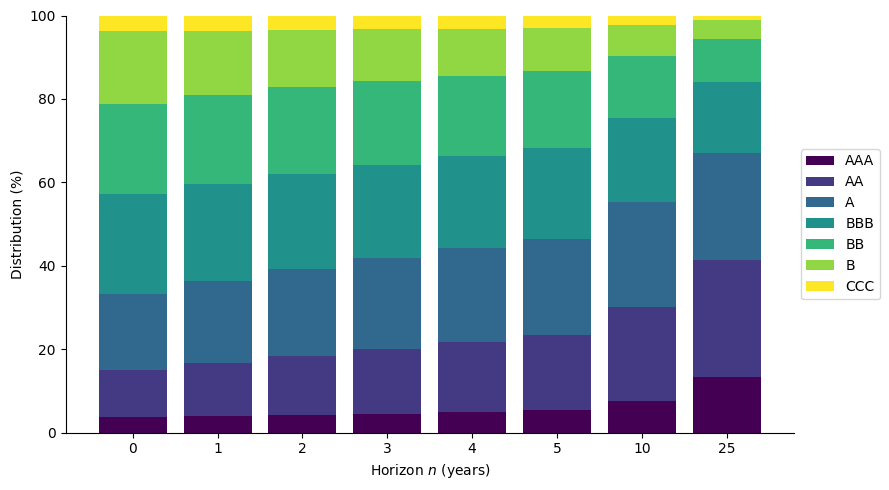

In [14]:
pi_0 = P1_pi0
P_star = np.linalg.matrix_power(P1, 500)
pi_star = P_star[0, :]

horizons = [0, 1, 2, 3, 4, 5, 10, 25]
all_pi = [pi_0]
pi_n = pi_0
for _ in range(max(horizons)):
    pi_n = P1.T @ pi_n
    all_pi.append(pi_n)
all_pi = np.array(all_pi)[horizons]  # (n_horizons, K)

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(horizons))
colors = plt.cm.viridis(np.linspace(0, 1, K))
for k in range(K):
    ax.bar([str(h) for h in horizons], 100 * all_pi[:, k], bottom=bottom,
           color=colors[k], label=RATINGS[k])
    bottom += 100 * all_pi[:, k]
ax.set_xlabel("Horizon $n$ (years)")
ax.set_ylabel("Distribution (%)")
ax.set_ylim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

## 8. Generator matrices

A continuous-time Markov chain is
described by a *generator* $\Lambda$ (off-diagonal entries $\geq 0$,
rows summing to 0) rather than a transition matrix. Given a 1-year
transition matrix $P$, $\Lambda = \log(P)$ recovers the (matrix)
logarithm, and $P(t) = \exp(t\Lambda)$ gives the implied $t$-year
transition matrix for any $t$, not just integers.

On a small, well-behaved toy example this simply works:

In [15]:
P_toy = np.array([
    [0.75, 0.15, 0.10],
    [0.10, 0.70, 0.20],
    [0.10, 0.10, 0.80],
])
Lambda_toy = logm(P_toy).real
print("Generator:\n", np.round(Lambda_toy, 4))

P_2y_toy = expm(2 * Lambda_toy)
P_2y_direct = P_toy @ P_toy
assert np.allclose(P_2y_toy, P_2y_direct, atol=1e-8)
print("\n2-year transition matrix (matches P @ P):\n", np.round(P_2y_toy, 4))

Generator:
 [[-0.3077  0.2031  0.1046]
 [ 0.1231 -0.3877  0.2647]
 [ 0.1231  0.1231 -0.2462]]

2-year transition matrix (matches P @ P):
 [[0.5875 0.2275 0.185 ]
 [0.165  0.525  0.31  ]
 [0.165  0.165  0.67  ]]


## 9. From a real transition matrix to a valid generator

Unlike the toy example above, $\log(P_1)$ for a real, empirically-estimated
transition matrix is **not** a valid generator -- it typically has small
negative off-diagonal entries, which have no meaningful interpretation as
transition rates.

`quanttoolbox.sustainable_finance.entropy.estimate_markov_generator`
implements Israel, Rosenthal & Wei (2001)'s two repair methods, each
producing a valid nearby generator.

In [16]:
Lambda_raw = logm(P1).real
n_negative = int((Lambda_raw[~np.eye(K, dtype=bool)] < 0).sum())
print(f"{n_negative} negative off-diagonal entries in the naive log(P1):")
print(np.round(100 * Lambda_raw, 3))

13 negative off-diagonal entries in the naive log(P1):
[[-7.6620e+00  6.4220e+00  5.4800e-01  4.6900e-01  2.4000e-01 -1.6000e-02
  -0.0000e+00]
 [ 4.7710e+00 -2.0606e+01  1.5453e+01 -1.0000e-03  3.1300e-01  7.2000e-02
  -1.0000e-03]
 [-2.6500e-01  2.0258e+01 -3.5179e+01  1.4959e+01  1.5000e-01  8.4000e-02
  -8.0000e-03]
 [ 1.0100e-01 -1.0500e+00  2.8259e+01 -4.0364e+01  1.3107e+01 -1.3300e-01
   7.9000e-02]
 [ 3.0000e-02  3.1200e-01 -1.7640e+00  2.8359e+01 -3.7897e+01  1.0827e+01
   1.3300e-01]
 [-5.0000e-03 -1.2000e-02  5.0100e-01 -2.2420e+00  3.0235e+01 -3.1487e+01
   3.0090e+00]
 [ 0.0000e+00 -2.4000e-02  1.9500e-01  4.7100e-01  3.6000e-01  1.6813e+01
  -1.7816e+01]]


In [17]:
Lambda1, Lambda2 = estimate_markov_generator(Lambda_raw)

assert (Lambda1[~np.eye(K, dtype=bool)] >= -1e-12).all()
assert (Lambda2[~np.eye(K, dtype=bool)] >= -1e-12).all()
assert np.allclose(Lambda1.sum(axis=1), 0, atol=1e-8)
assert np.allclose(Lambda2.sum(axis=1), 0, atol=1e-8)

P1_repaired = expm(Lambda1)
pd.DataFrame(100 * P1_repaired, index=RATINGS, columns=RATINGS).round(2)

,AAA,AA,A,BBB,BB,B,CCC
AAA,92.75,5.66,0.91,0.45,0.23,0.01,0.00
AA,4.17,82.73,11.85,0.89,0.29,0.07,0.00
A,0.40,15.51,72.78,10.39,0.81,0.10,0.01
BBB,0.12,2.11,19.60,68.69,8.92,0.50,0.07
BB,0.04,0.43,2.79,19.26,69.65,7.61,0.23
B,0.01,0.09,0.65,2.98,21.22,72.70,2.36
CCC,0.00,0.02,0.25,0.58,2.19,13.10,83.86


## 10. Continuous-time migration probabilities

With a valid generator in hand, $P(t) = \exp(t\Lambda)$ gives migration
probabilities at any horizon $t$ -- here, the probability of being in (or
having migrated out of) the best/worst rating groups as a continuous
function of time, plus the instantaneous rate of change $\partial_t \pi(t)
= \Lambda\, P(t)$.

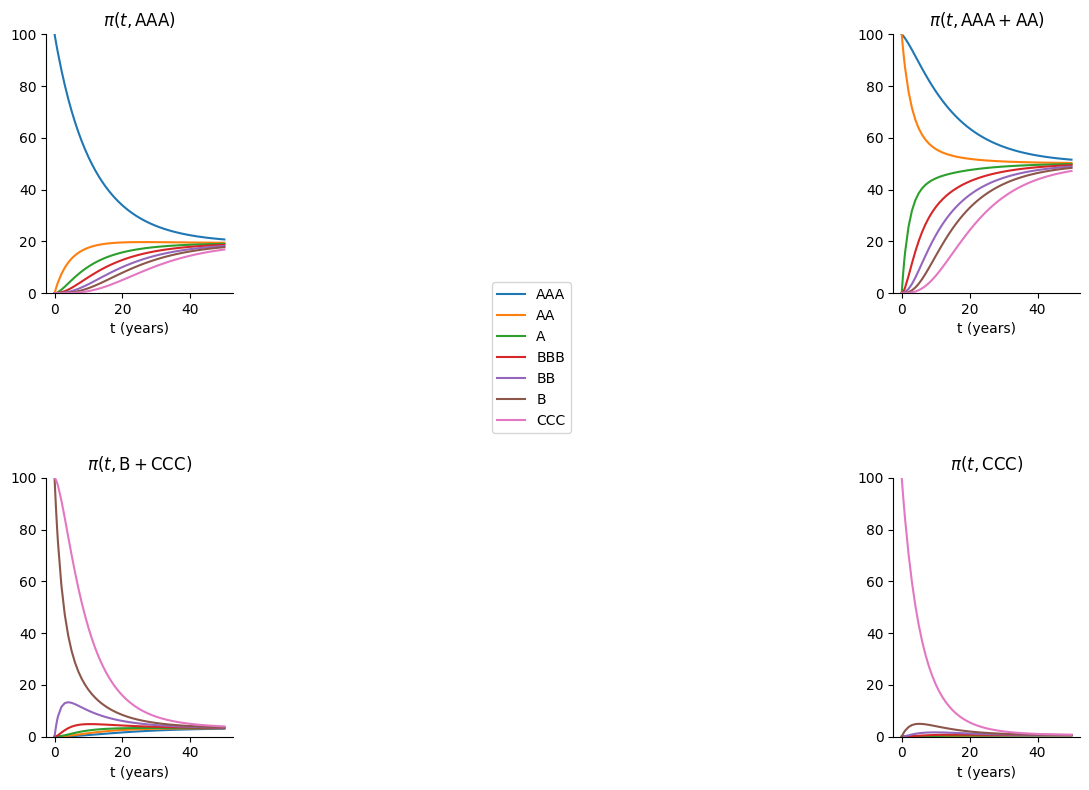

In [18]:
Lambda = Lambda1
t_grid = np.concatenate([np.arange(0, 1.05, 0.1), np.arange(2, 51, 1)])

groups = {"AAA": [0], "AAA+AA": [0, 1], "B+CCC": [5, 6], "CCC": [6]}
probs = {name: np.zeros((len(t_grid), K)) for name in groups}

for i, t in enumerate(t_grid):
    Pt = expm(t * Lambda)
    for name, cols in groups.items():
        probs[name][i, :] = Pt[:, cols].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, arr) in zip(axes.flat, probs.items()):
    for k in range(K):
        ax.plot(t_grid, 100 * arr[:, k], label=RATINGS[k])
    ax.set_title(f"$\\pi(t, \\mathrm{{{name}}})$")
    ax.set_xlabel("t (years)")
    ax.set_ylim(0, 100)
axes[0, 0].legend(loc="center left", bbox_to_anchor=(2.35, -0.25), ncol=1)
fig.tight_layout()
plt.show()

Worst-in-class $\to$ best-in-class migration probability (and best-in-class $\to$ worst-in-class), with their instantaneous rates $\Lambda\,P(t)$ and $\Lambda^2\,P(t)$:

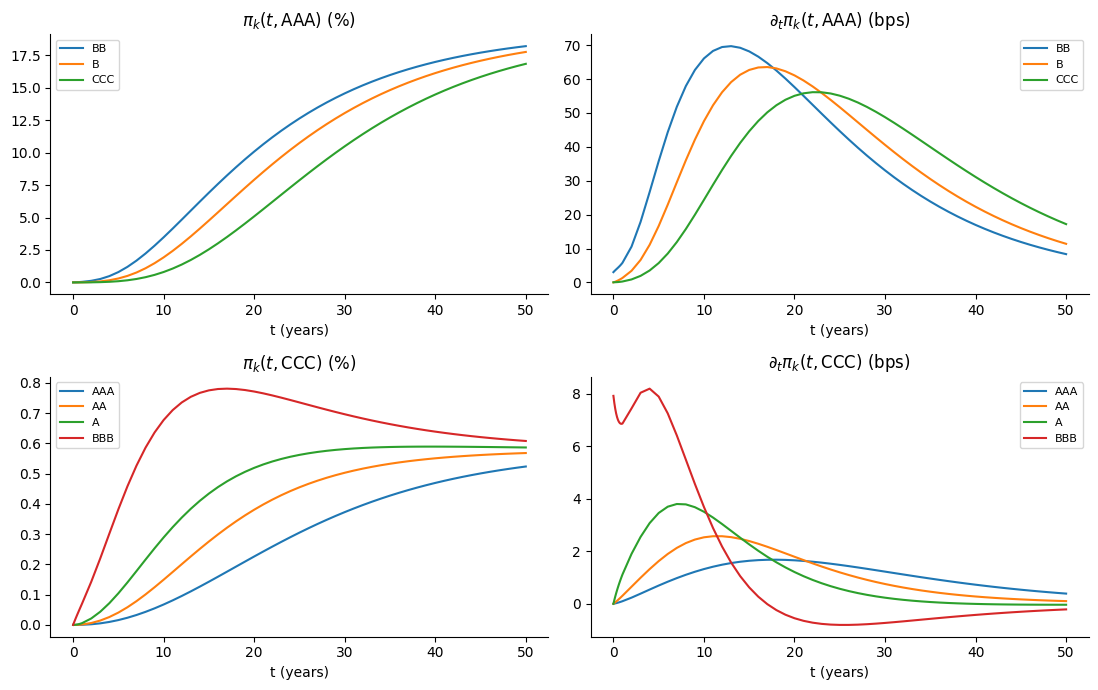

In [19]:
def group_migration(Lambda, t_grid, source, target, order=0):
    out = np.zeros((len(t_grid), len(source)))
    for i, t in enumerate(t_grid):
        M = expm(t * Lambda)
        for _ in range(order):
            M = Lambda @ M
        out[i, :] = M[np.ix_(source, [target])].sum(axis=1)
    return out

wic, bic = [4, 5, 6], [0, 1, 2, 3]
pi0_wic_to_bic = group_migration(Lambda, t_grid, wic, 0, order=0)
pi1_wic_to_bic = group_migration(Lambda, t_grid, wic, 0, order=1)
pi0_bic_to_wic = group_migration(Lambda, t_grid, bic, 6, order=0)
pi1_bic_to_wic = group_migration(Lambda, t_grid, bic, 6, order=1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [
    (pi0_wic_to_bic, "$\\pi_k(t, \\mathrm{AAA})$ (%)", 100, [RATINGS[i] for i in wic]),
    (pi1_wic_to_bic, "$\\partial_t\\pi_k(t, \\mathrm{AAA})$ (bps)", 10000, [RATINGS[i] for i in wic]),
    (pi0_bic_to_wic, "$\\pi_k(t, \\mathrm{CCC})$ (%)", 100, [RATINGS[i] for i in bic]),
    (pi1_bic_to_wic, "$\\partial_t\\pi_k(t, \\mathrm{CCC})$ (bps)", 10000, [RATINGS[i] for i in bic]),
]
for ax, (data, title, scale, labels) in zip(axes.flat, panels):
    for j, lab in enumerate(labels):
        ax.plot(t_grid, scale * data[:, j], label=lab)
    ax.set_title(title)
    ax.set_xlabel("t (years)")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 11. Comparing rating stability across systems

"Stability" here means: starting from
today's rating, what's the probability of *not having migrated at all*
by horizon $t$? That's $\sum_i P_{ii}(t)$ (summed diagonal of $P(t)$),
normalized to 1 at $t=0$. Comparing this across a real credit-rating
system (Kavvathas (2001)'s widely-cited 8-state agency matrix, with an
absorbing Default state excluded from the sum) and the two ESG-rating
providers shows how much less stable ESG ratings are than credit
ratings over the same horizon.

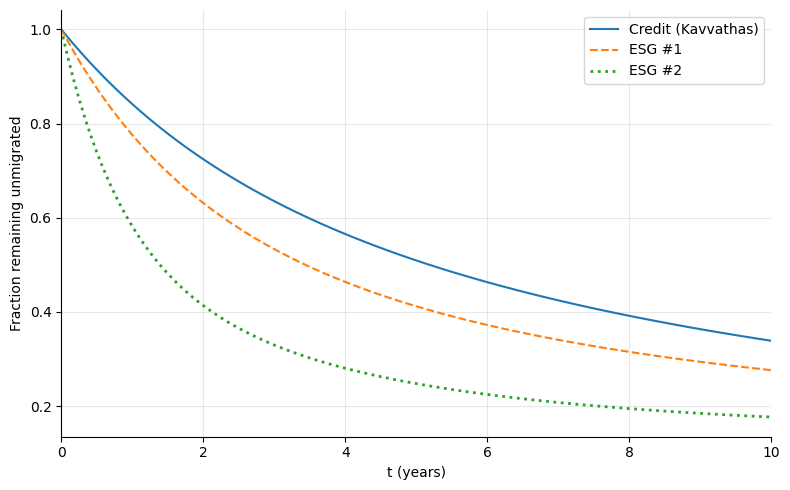

In [20]:
RATINGS_8 = RATINGS + ["D"]
P_kavvathas = np.array([
    [92.82,  6.50,  0.56,  0.06,  0.06,  0.00,  0.00,   0.00],
    [ 0.63, 91.87,  6.64,  0.65,  0.06,  0.11,  0.04,   0.00],
    [ 0.08,  2.26, 91.66,  5.11,  0.61,  0.23,  0.01,   0.04],
    [ 0.05,  0.27,  5.84, 87.74,  4.74,  0.98,  0.16,   0.22],
    [ 0.04,  0.11,  0.64,  7.85, 81.14,  8.27,  0.89,   1.06],
    [ 0.00,  0.11,  0.30,  0.42,  6.75, 83.07,  3.86,   5.49],
    [ 0.19,  0.00,  0.38,  0.75,  2.44, 12.03, 60.71,  23.50],
    [ 0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00, 100.00],
]) / 100
P_kavvathas = P_kavvathas / P_kavvathas.sum(axis=1, keepdims=True)

Lambda_credit = estimate_markov_generator(logm(P_kavvathas).real)[0]
Lambda_esg1 = estimate_markov_generator(logm(P1).real)[0]
Lambda_esg2 = estimate_markov_generator(12 * logm(P2).real)[0]

t_grid_m = np.arange(0, 10 + 1 / 12, 1 / 12)
stability = np.zeros((len(t_grid_m), 3))
for i, t in enumerate(t_grid_m):
    stability[i, 0] = np.diag(expm(t * Lambda_credit))[:-1].sum()  # exclude Default
    stability[i, 1] = np.diag(expm(t * Lambda_esg1)).sum()
    stability[i, 2] = np.diag(expm(t * Lambda_esg2)).sum()
stability = stability / stability[0, :]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_grid_m, stability[:, 0], "-", label="Credit (Kavvathas)")
ax.plot(t_grid_m, stability[:, 1], "--", label="ESG #1")
ax.plot(t_grid_m, stability[:, 2], ":", label="ESG #2", linewidth=2)
ax.set_xlabel("t (years)")
ax.set_ylabel("Fraction remaining unmigrated")
ax.set_xlim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()